### Import packages

In [556]:
%load_ext autoreload
%autoreload 2

#Import general libs you'll need
import os
import geopandas as gpd
import pandas as pd
from shapely.geometry import Point
import numpy as np

# Import functions from main
from main import ATL_AGG_CONFIG

# Import functions from the utils
from utils import readers, analysis, processing
from utils import plotter
from utils.create_las_swath import create_als_swath, transform_als_swath
from utils.datum_transforms import convert_3d_nad83_to_wgs84
from utils.datum_transforms import get_geoid_height



The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### Identify files



In [51]:
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl03_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl03_name = 'ATL03_20250616013703_00052802_007_01.h5'
atl03_name = 'ATL03_20181215070448_11860106_007_01.h5'
atl03_file = os.path.join(atl03_dir, atl03_name)

# Define ATL08 File /home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/austin'
atl08_dir = '/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/IS2/footprint_exp/austin_data'
atl08_name = 'ATL08_20250616013703_00052802_007_01.h5'
atl08_name = 'ATL08_20181215070448_11860106_007_01.h5'
atl08_file = os.path.join(atl08_dir, atl08_name)

# Define the ground track of interest
gt = 'gt2l'

# Identify ATX AOI
extent_file = '/home/ejg2736/dev/icesat2_topobathy/data/austin_laz_bigtex.gpkg'

# ALS Geoid File
als_geoid_file = '/home/ejg2736/dev/geoid/agisoft/us_noaa_g2018u0.tif'

### Get photon rate dataframe


In [558]:
# Get photon rate DF
df_ph = readers.read_photon_dataframe(atl03_file, gt, atl08_file)


In [559]:
# Filter df_ph
extent_gdf = gpd.read_file(extent_file)
df_ph = processing.filter_df_by_extent(df_ph, extent_gdf.total_bounds)


### Plot output 

Check to make sure it plots correctly

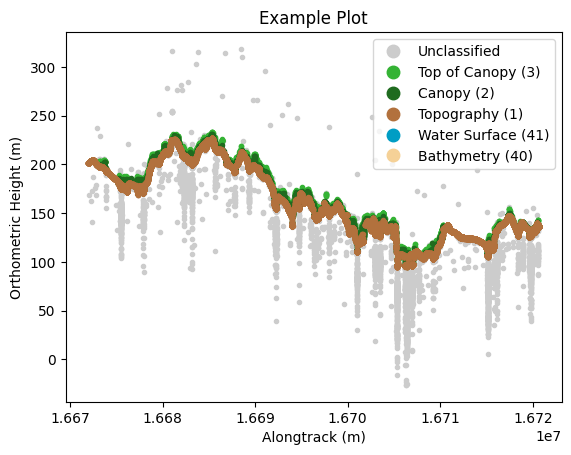

In [54]:
import matplotlib.pyplot as plt
plotter.plot_alongtrack(df_ph.alongtrack, df_ph.h_ph, df_ph.atl08_class,'Example Plot')

### Process ALS Swath

Load the ALS Swath and preprocess it 

In [55]:
atl03_basename = os.path.basename(atl03_name).split('.h5')[0]
print(atl03_basename)

ATL03_20181215070448_11860106_007_01


In [56]:
# Load swath if available
als_outdir = '/home/ejg2736/dev/icesat2_topobathy/als_swaths'
file_out_name = f"{os.path.basename(atl03_name).split('.h5')[0]}_{gt}"
als_outfile = os.path.join(als_outdir, f'als_{file_out_name}.pqt')                
if os.path.exists(als_outfile):
    als_swath = pd.read_parquet(als_outfile)
else:
    als_swath = create_als_swath(extent_gdf, df_ph)
    als_swath = transform_als_swath(als_swath, 
        'EPSG:32614', 
        source_geoid_file=als_geoid_file,
        target_geoid_file=None, 
        input_units='feet', 
        source_datum='nad83'
    )
    als_swath.to_parquet(als_outfile)

/home/ejg2736/miniconda3/envs/spyder_pr/lib/python3.9/site-packages/IPython/core/pylabtools.py:152: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


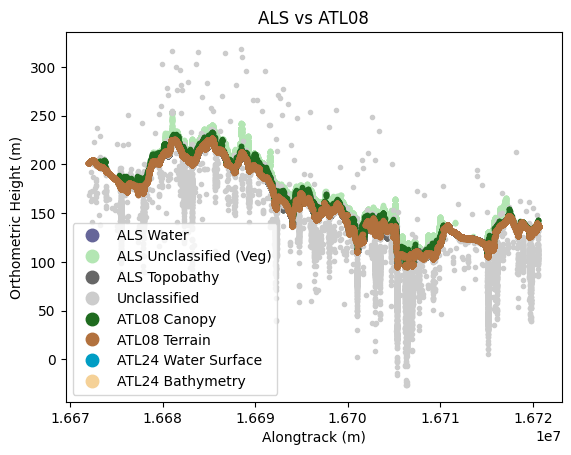

In [57]:
from utils.plotter import plot_alongtrack_atl_als3
plot_alongtrack_atl_als3(df_ph, als_swath,'ALS vs ATL08')

### Perform Geolocation Offset

Fine tune the fit between the ICESat-2 and the ALS swath.

In [58]:
%load_ext autoreload
%autoreload 2

# Call geolocation offset script
from utils.geolocation import create_interpolator


df_ph['crosstrack'] = 0


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [59]:
als_surface_interpolator = create_interpolator(als_swath, grid_resolution=1)

In [60]:
from utils.geolocation import calculate_mae_cost
from scipy.optimize import minimize, brute, fmin


search_grid = (slice(-10, 10, 0.5), slice(-10, 10, 0.5))

result = brute(
    calculate_mae_cost, 
    ranges=search_grid, 
    args=(df_ph.alongtrack[df_ph.atl08_class == 1], 
    df_ph.crosstrack[df_ph.atl08_class == 1], 
    df_ph.h_ph[df_ph.atl08_class == 1], als_surface_interpolator),
    finish=fmin, 
    full_output=True 
)

optimal_shift_at, optimal_shift_xt = result[0]
best_mae = result[1]

print(f"AT shift: {optimal_shift_at:.2f} m")
print(f"XT shift: {optimal_shift_xt:.2f} m")
print(f"Best MAE: {result[1]:.2f} m")

AT shift: 0.02 m
XT shift: 2.17 m
Best MAE: 0.72 m


In [61]:
als_swath['alongtrack'] = als_swath['alongtrack'] - optimal_shift_at
als_swath['crosstrack'] = als_swath['crosstrack'] - optimal_shift_xt

In [62]:
import geopandas as gpd

# Define roughly the bounding box for Austin (Min Long, Min Lat, Max Long, Max Lat)
# austin_bbox = (-98.1, 30.1, -97.5, 30.5)

# Load ONLY the buildings within that bounding box from the local file
# Note: Geopandas can read directly from the zipped file!
# file_path = "/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/footprint/Texas.geojson"
# austin_buildings = gpd.read_file(file_path, bbox=austin_bbox)

# print(f"Loaded {len(austin_buildings)} buildings in the Austin area.")
austin_building_file = "/home/ejg2736/network_drives/walker/exports/nfs_share/Data/workspace/footprint/austin_bldgs.gpkg"
#austin_buildings.to_file( austin_building_file,driver='GPKG')

In [63]:
austin_buildings = gpd.read_file(austin_building_file)
len(austin_buildings)

405561

In [64]:
%load_ext autoreload
%autoreload 2

from utils.create_las_swath import prepare_icesat2_track
from utils.building_processing import find_intersected_buildings, convert_buildings_to_atxt

# 1. Prepare data once
gdf_buildings_utm = austin_buildings.to_crs('EPSG:32614')

is2_line_utm, line_x, line_y, line_at_dist = prepare_icesat2_track(
    df_ph, utm_epsg='EPSG:32614', resolution_m=10.0
)

# 2. Pipeline the data through the modular functions
candidates_utm = find_intersected_buildings(
    is2_line_utm, gdf_buildings_utm, buffer_meters=5.0, building_filter_size=100.0
)

buildings_atxt = convert_buildings_to_atxt(
    candidates_utm, is2_line_utm, line_x, line_y, line_at_dist
)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [65]:
type(is2_line_utm)


shapely.geometry.linestring.LineString

In [66]:
data = {
    'name': [f'{atl03_basename}_{gt}'],
    'geometry': [is2_line_utm]
}

# 3. Initialize the GeoDataFrame with a CRS
gdf = gpd.GeoDataFrame(data, crs="EPSG:32614")

# 4. Write to GeoPackage
# Use 'engine="pyogrio"' for high-performance writing
gdf.to_file(f"test_path2.gpkg", layer='layer',driver="GPKG", engine="pyogrio")

In [67]:
candidates_utm.to_file('candidate_buildings.gpkg', driver='GPKG',index=True)

In [68]:
candidates_utm

,release,capture_dates_range,geometry,area_sqm
1957,2,5/27/2018-11/20/2018,"POLYGON ((629968.424 3372826.101, 629981.269 3...",405.531133
1997,2,5/27/2018-11/20/2018,"POLYGON ((629863.506 3371638.335, 629878.651 3...",242.443517
2005,2,5/27/2018-11/20/2018,"POLYGON ((629840.827 3370918.113, 629823.187 3...",301.854620
2170,2,5/27/2018-11/20/2018,"POLYGON ((629388.239 3365875.626, 629391.353 3...",244.475327
2479,2,5/27/2018-11/20/2018,"POLYGON ((628602.235 3356364.014, 628596.547 3...",948.555088
...,...,...,...,...
393369,2,5/27/2018-11/20/2018,"POLYGON ((630180.122 3374951.261, 630163.616 3...",264.462331
393507,2,5/27/2018-11/20/2018,"POLYGON ((629859.253 3371319.932, 629851.856 3...",100.268707
393566,2,5/27/2018-11/20/2018,"POLYGON ((629735.921 3369998.713, 629732.198 3...",132.758450
393806,2,5/27/2018-11/20/2018,"POLYGON ((629343.421 3365508.525, 629337.074 3...",207.499389


In [69]:
%load_ext autoreload
%autoreload 2

from utils.building_processing import filter_grazing_hits

hit_buildings = filter_grazing_hits(buildings_atxt)

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload
Filtered out 220 grazing hits.


In [233]:
hit_buildings

,release,capture_dates_range,geometry,area_sqm
2479,2,5/27/2018-11/20/2018,"POLYGON ((16697593.913 19.772, 16697593.133 13...",948.555088
3077,2,5/27/2018-11/20/2018,"POLYGON ((16692003.702 -7.955, 16692008.491 4....",128.274839
17636,2,5/27/2018-11/20/2018,"POLYGON ((16696072.155 14.578, 16696044.14 24....",2093.226140
17996,2,5/27/2018-11/20/2018,"POLYGON ((16687927.863 -12.715, 16687935.342 3...",219.840751
18407,2,5/27/2018-11/20/2018,"POLYGON ((16700748.589 -11.659, 16700758.303 -...",225.598567
33037,2,5/27/2018-11/20/2018,"POLYGON ((16700222.2 1.813, 16700256.186 -52.8...",1463.887062
63548,2,5/27/2018-11/20/2018,"POLYGON ((16684781.468 -8.738, 16684779.983 8....",741.597573
79229,2,5/27/2018-11/20/2018,"POLYGON ((16684678.297 9.105, 16684674.041 -4....",303.619521
79245,2,5/27/2018-11/20/2018,"POLYGON ((16685624.216 13.749, 16685604.935 20...",487.151653
81083,2,5/27/2018-11/20/2018,"POLYGON ((16679672.894 9.244, 16679634.346 -2....",2163.954690


In [522]:
# target_building_id = 273324
# target_building_id = 17636
target_building_id = 159174
# target_building_id = 2479
target_building = hit_buildings.loc[target_building_id].geometry.buffer(20) 

In [523]:
from utils.building_processing import clip_als_to_buffered_building
target_als = clip_als_to_buffered_building(als_swath, target_building, buffer_m=1.0)
target_als = target_als[np.abs(target_als.crosstrack) < 6] 




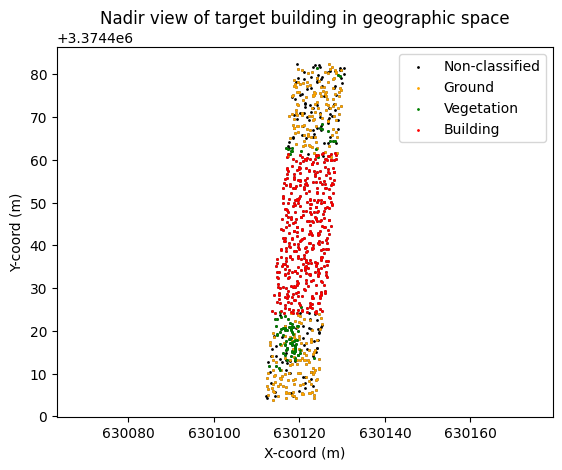

In [524]:
cmap = plt.get_cmap('viridis')
# colors = cmap(target_als.h_norm[target_als.classification==6]) 
plt.scatter(target_als.x, target_als.y,c='k',label='Non-classified',s=1)
plt.scatter(target_als.x[target_als.classification==2], target_als.y[target_als.classification==2],c='orange',s=1,label='Ground')
plt.scatter(target_als.x[target_als.classification==3], target_als.y[target_als.classification==3],c='g',s=1,label='Vegetation')
plt.scatter(target_als.x[target_als.classification==6], target_als.y[target_als.classification==6],c='r',s=1,label='Building')
plt.legend()
plt.title('Nadir view of target building in geographic space')
plt.xlabel('X-coord (m)')
plt.ylabel('Y-coord (m)')
plt.axis('equal')
plt.show()

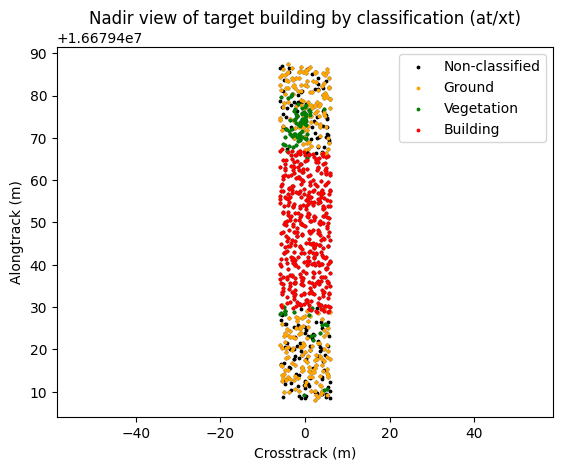

In [525]:
cmap = plt.get_cmap('viridis')
# colors = cmap(target_als.h_norm[target_als.classification==6]) 
plt.scatter(target_als.crosstrack, target_als.alongtrack,c='k',label='Non-classified',s=3)
plt.scatter(target_als.crosstrack[target_als.classification==2], target_als.alongtrack[target_als.classification==2],c='orange',s=3,label='Ground')
plt.scatter(target_als.crosstrack[target_als.classification==3], target_als.alongtrack[target_als.classification==3],c='g',s=3,label='Vegetation')
plt.scatter(target_als.crosstrack[target_als.classification==6], target_als.alongtrack[target_als.classification==6],c='r',s=3,label='Building')
plt.legend()
plt.title('Nadir view of target building by classification (at/xt)')
plt.xlabel('Crosstrack (m)')
plt.ylabel('Alongtrack (m)')
plt.axis('equal')
plt.show()

In [563]:
%load_ext autoreload
%autoreload 2
import pdb 
from utils.building_processing import extract_building_edges_2d
edge = extract_building_edges_2d(target_als, min_clearance_m=7.0)
edge


The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


{'entry': {'slope': np.float64(-0.17491742471950106),
  'intercept': np.float64(16679429.882593216),
  'valid': True,
  'reason': 'Valid Edge',
  'roof_median_h': np.float64(8.988551999999999),
  'roof_iqr': np.float64(0.06705600000003642)},
 'exit': {'slope': np.float64(-0.12406111616770496),
  'intercept': np.float64(16679466.35102328),
  'valid': True,
  'reason': 'Valid Edge',
  'roof_median_h': np.float64(8.29970400000002),
  'roof_iqr': np.float64(0.11506200000000888)}}

In [ ]:
from utils.building_processing import create_line
x_entry,y_entry = create_line(edge['entry']['slope'], edge['entry']['intercept'], x_start=-7, x_stop = 7)
x_exit,y_exit = create_line(edge['exit']['slope'], edge['exit']['intercept'], x_start=-7, x_stop = 7)

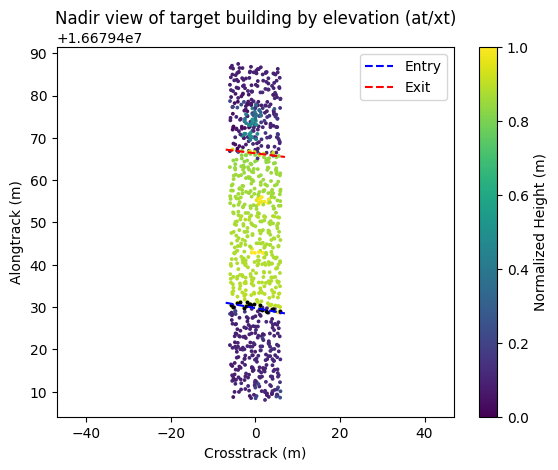

In [ ]:
cmap = plt.get_cmap('viridis')
colors = cmap(target_als.h_norm) 
plt.scatter(target_als.crosstrack, target_als.alongtrack,c=target_als.h_norm,s=3)
plt.scatter(obstructions.crosstrack,obstructions.alongtrack, s=3, c='black')
plt.plot(x_entry,y_entry,'b--',label='Entry')
plt.plot(x_exit,y_exit,'r--',label='Exit')
cbar = plt.colorbar()
cbar.set_label('Normalized Height (m)')
plt.title('Nadir view of target building by elevation (at/xt)')
plt.xlabel('Crosstrack (m)')
plt.ylabel('Alongtrack (m)')
plt.legend()
plt.axis('equal')
plt.show()

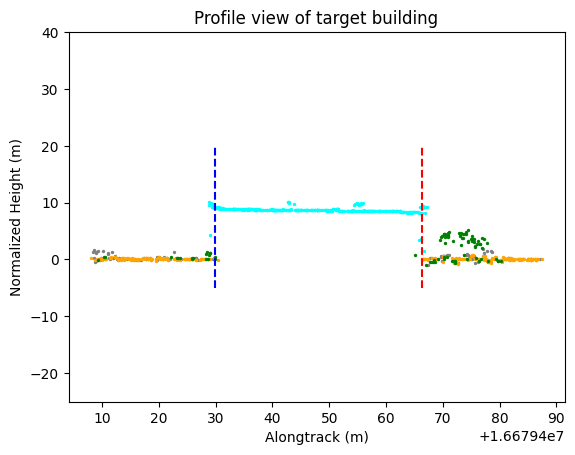

In [578]:
plt.scatter(target_als.alongtrack[target_als.classification == 1],target_als.h_norm[target_als.classification == 1],c='gray',s=2,label='Non-classified')
plt.scatter(target_als.alongtrack[target_als.classification == 6],target_als.h_norm[target_als.classification == 6],c='cyan',s=2,label='Building')
plt.scatter(target_als.alongtrack[target_als.classification == 2],target_als.h_norm[target_als.classification == 2],c='orange',s=2,label='Ground')
plt.scatter(target_als.alongtrack[target_als.classification == 3],target_als.h_norm[target_als.classification == 3],c='green',s=2,label='Vegetation')

plt.plot([edge['entry']['intercept'],edge['entry']['intercept']],[-5,20],'b--',label = 'Entry')
plt.plot([edge['exit']['intercept'],edge['exit']['intercept']],[-5,20],'r--',label = 'Exit')
plt.title('Profile view of target building')
plt.xlabel('Alongtrack (m)')
plt.ylabel('Normalized Height (m)')
plt.axis('equal')
plt.show()

In [653]:
target_ph = df_ph[(edge['exit']['intercept'] + 50) > df_ph.alongtrack] 
target_ph = target_ph[(edge['exit']['intercept'] - 50) < df_ph.alongtrack] 
print(target_ph.columns)
# target_ph = target_ph[target_ph.h_norm < 130]
# target_ph = target_ph[target_ph.h_norm > -10]
len(target_ph)

Index(['latitude', 'longitude', 'h_ph', 'quality_ph', 'delta_time',
       'alongtrack', 'solar_elevation', 'atl08_class', 'h_norm'],
      dtype='object')


/tmp/ipykernel_801157/1728685980.py:2: UserWarning: Boolean Series key will be reindexed to match DataFrame index.
  target_ph = target_ph[(edge['exit']['intercept'] - 50) < df_ph.alongtrack]


102

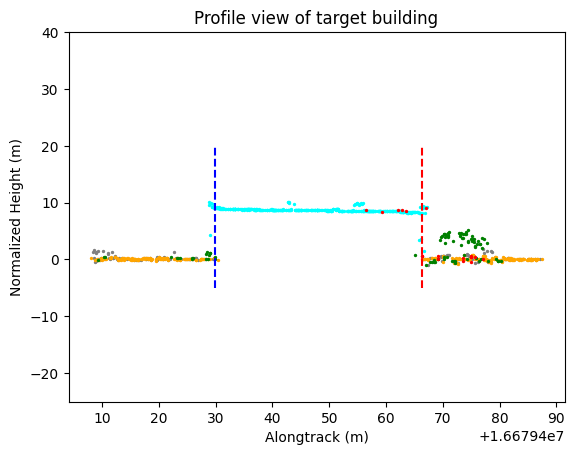

In [ ]:
plt.scatter(target_als.alongtrack[target_als.classification == 1],target_als.h_norm[target_als.classification == 1],c='gray',s=2,label='Non-classified')
plt.scatter(target_als.alongtrack[target_als.classification == 6],target_als.h_norm[target_als.classification == 6],c='cyan',s=2,label='Building')
plt.scatter(target_als.alongtrack[target_als.classification == 2],target_als.h_norm[target_als.classification == 2],c='orange',s=2,label='Ground')
plt.scatter(target_als.alongtrack[target_als.classification == 3],target_als.h_norm[target_als.classification == 3],c='green',s=2,label='Vegetation')
plt.scatter(target_ph.alongtrack,target_ph.h_norm,c='red',s=2,label='IS2')


plt.plot([edge['entry']['intercept'],edge['entry']['intercept']],[-5,20],'b--',label = 'Entry')
plt.plot([edge['exit']['intercept'],edge['exit']['intercept']],[-5,20],'r--',label = 'Exit')
plt.title('Profile view of target building')
plt.xlabel('Alongtrack (m)')
plt.ylabel('Normalized Height (m)')
plt.axis('equal')
plt.show()

{'slope': np.float64(-0.17491742471950106),
 'intercept': np.float64(16679429.882593216),
 'valid': True,
 'reason': 'Valid Edge',
 'roof_median_h': np.float64(8.988551999999999),
 'roof_iqr': np.float64(0.06705600000003642)}

In [656]:
%load_ext autoreload
%autoreload 2

from utils.building_processing import calculate_orthogonal_distance, classify_photons
target_ph['crosstrack'] = 0
target_ph = calculate_orthogonal_distance(target_ph, edge['entry'], 'entry', threshold_m=10.0)

target_ph = classify_photons(target_ph, edge['entry']['roof_median_h'], z_tolerance=1.0)

target_ph

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


,latitude,longitude,h_ph,quality_ph,delta_time,alongtrack,solar_elevation,atl08_class,h_norm,crosstrack,dist_to_wall,target_class
5458477,30.495469,-97.644136,202.169113,0,3.009314e+07,1.667942e+07,-77.315727,1,-0.109711,0,-9.581398,ground
5458478,30.495463,-97.644137,202.189804,0,3.009314e+07,1.667942e+07,-77.315727,1,-0.087326,0,-8.881198,ground
5458479,30.495456,-97.644137,202.437225,0,3.009314e+07,1.667942e+07,-77.315727,1,0.158585,0,-8.180891,ground
5458480,30.495450,-97.644138,202.510452,0,3.009314e+07,1.667942e+07,-77.315727,1,0.227295,0,-7.480684,ground
5458481,30.495450,-97.644138,202.351898,0,3.009314e+07,1.667942e+07,-77.315727,1,0.062225,0,-7.480788,ground
5458482,30.495443,-97.644139,202.370239,0,3.009314e+07,1.667942e+07,-77.315727,1,0.072983,0,-6.780574,ground
5458483,30.495443,-97.644139,202.573914,0,3.009314e+07,1.667942e+07,-77.315727,1,0.269226,0,-6.780470,ground
5458484,30.495437,-97.644139,202.408615,0,3.009314e+07,1.667942e+07,-77.315727,1,0.096756,0,-6.080355,ground
5458485,30.495431,-97.644140,202.420334,0,3.009314e+07,1.667942e+07,-77.315727,1,0.101685,0,-5.380128,ground
5458486,30.495418,-97.644142,202.607773,0,3.009314e+07,1.667943e+07,-77.315727,1,0.282776,0,-3.979545,ground


In [657]:
from utils.building_processing import compute_esf

esf_df = compute_esf(target_ph, min_dist=-10.0, max_dist=10.0, bin_size=0.5)